In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

import numpy as np
from numpy.typing import NDArray
import pandas as pd
from bisect import bisect_left, bisect_right

from bloodmoon.io import simulation_files
from bloodmoon.coords import shift2pos, shift2angle, angle2shift, equatorial2shift
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.mask import codedmask, count, decode
from bloodmoon.mask import variance, snratio
from bloodmoon.optim import model_sky

import darksun as ds
from darksun.data import DataLoader, CatalogueLoader
from darksun.utils import savefig_to

from old_bm_model import model_sky_bm as bm_sky

In [2]:
# save plot and images
SAVE_TO: str | Path = '/home/edoardo/Desktop/PSF_newSG'
SAVE_THINGS: bool = False

In [3]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 5
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = True

In [4]:
def config_snrlim(
    bins: NDArray,
    start: int | float | None,
    stop: int | float | None,
) -> tuple[slice, slice]:
    """
    Configures significance histograms values to show.

    Args:
        bins (NDArray): Bins array values.
        start (int | float): Inf significance limit.
        stop (int | float): Sup significance limit.
    
    Returns:
        output (tuple[slice, slice]):
            - slice obj for bins values
            - slice obj for histogram values
    """
    i_min = (
        bisect_right(bins, start) - 1 if start is not None else None
    )
    i_max = (
        bisect_left(bins, stop) if stop is not None else None
    )
    slice_bins = slice(i_min, i_max)
    slice_hist = slice(i_min, i_max - 1 if i_max else None)
    return slice_bins, slice_hist

In [5]:
def extract_catalogue_angular_coords(
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    Extracts the catalogue sources angular coords.
    """
    s, txs, tys = [], [], []
    for sourceID in np.unique(catalogue.DLdata['ID']):
        source = catalogue.DLdata[(catalogue.DLdata['ID'] == sourceID)][0]    # NOTE: for new WISEMAN sims
        sx, sy = equatorial2shift(sdl, camera, source['RA'], source['DEC'])
        thetax, thetay = map(lambda x: shift2angle(camera, x), (sx, sy))
        s.append(sourceID)
        txs.append(thetax)
        tys.append(thetay)

    df = pd.DataFrame(
        {'ID': s, 'THETAX': txs, 'THETAY': tys}
    )
    return df

In [6]:
# load filepaths
mask_path, simul_data, _ = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    
)

wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

In [7]:
# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])

detector = count(wfm, sdlA.DLdata)[0]
true_sky = decode(wfm, detector)
varmap = variance(wfm, detector)

ycut, xcut = UPS_Y * 30, UPS_X * 20
true_skysnr = ds.unframe(snratio(true_sky, varmap), ycut, xcut)

## USING BULK MASK with 1.5 mm cover ##


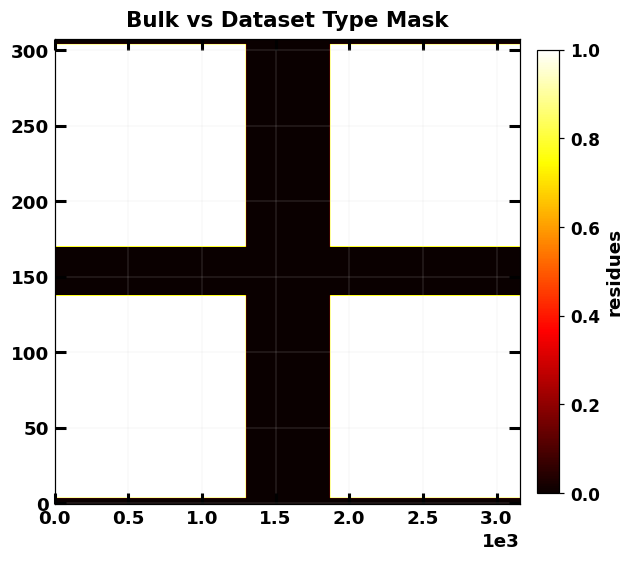

In [8]:
ds.image_plot(
    ds.map4image(
        img=wfm.bulk,
        title='Bulk vs Dataset Type Mask',
        cbarlabel='residues',
        img_kwargs={
            'aspect': wfm.shape_detector[1] / wfm.shape_detector[0],
            'cmap': 'hot',
        },
    )
)

In [9]:
SOURCE_ID = 'scox1'

In [10]:
catalogue_angular_coords = extract_catalogue_angular_coords(catalogueA, sdlA, wfm)
under_inspection = catalogue_angular_coords[(catalogue_angular_coords['ID'] == SOURCE_ID)]

thetax, thetay = np.array(under_inspection['THETAX'])[0], np.array(under_inspection['THETAY'])[0]
shiftx, shifty = map(
    lambda x: angle2shift(wfm, x),
    (thetax, thetay),
)
i, j = shift2pos(wfm, shiftx, shifty)
print(
    f'{SOURCE_ID.upper()} angular coords (x, y): {thetax:.5f}, {thetay:.5f} [deg]\n'
    f'{SOURCE_ID.upper()} cartesian coords (x, y): {shiftx:.5f}, {shifty:.5f} [mm]\n'
    f'{SOURCE_ID.upper()} pixel coords (row, col): {i}, {j} [px]\n'
)

pxdim_y, pxdim_x = (
    wfm.specs.mask_deltay / UPS_Y,
    wfm.specs.mask_deltax / UPS_X,
)

crp = (
    int(wfm.specs.slit_deltay * UPS_Y / wfm.specs.mask_deltay + 5),
    int(wfm.specs.slit_deltax * UPS_X / wfm.specs.mask_deltax + 5),
)

SCOX1 angular coords (x, y): 12.20227, 21.02514 [deg]
SCOX1 cartesian coords (x, y): 43.90940, 78.04581 [mm]
SCOX1 pixel coords (row, col): 570, 5057 [px]



## **Shadowgrams CFR**

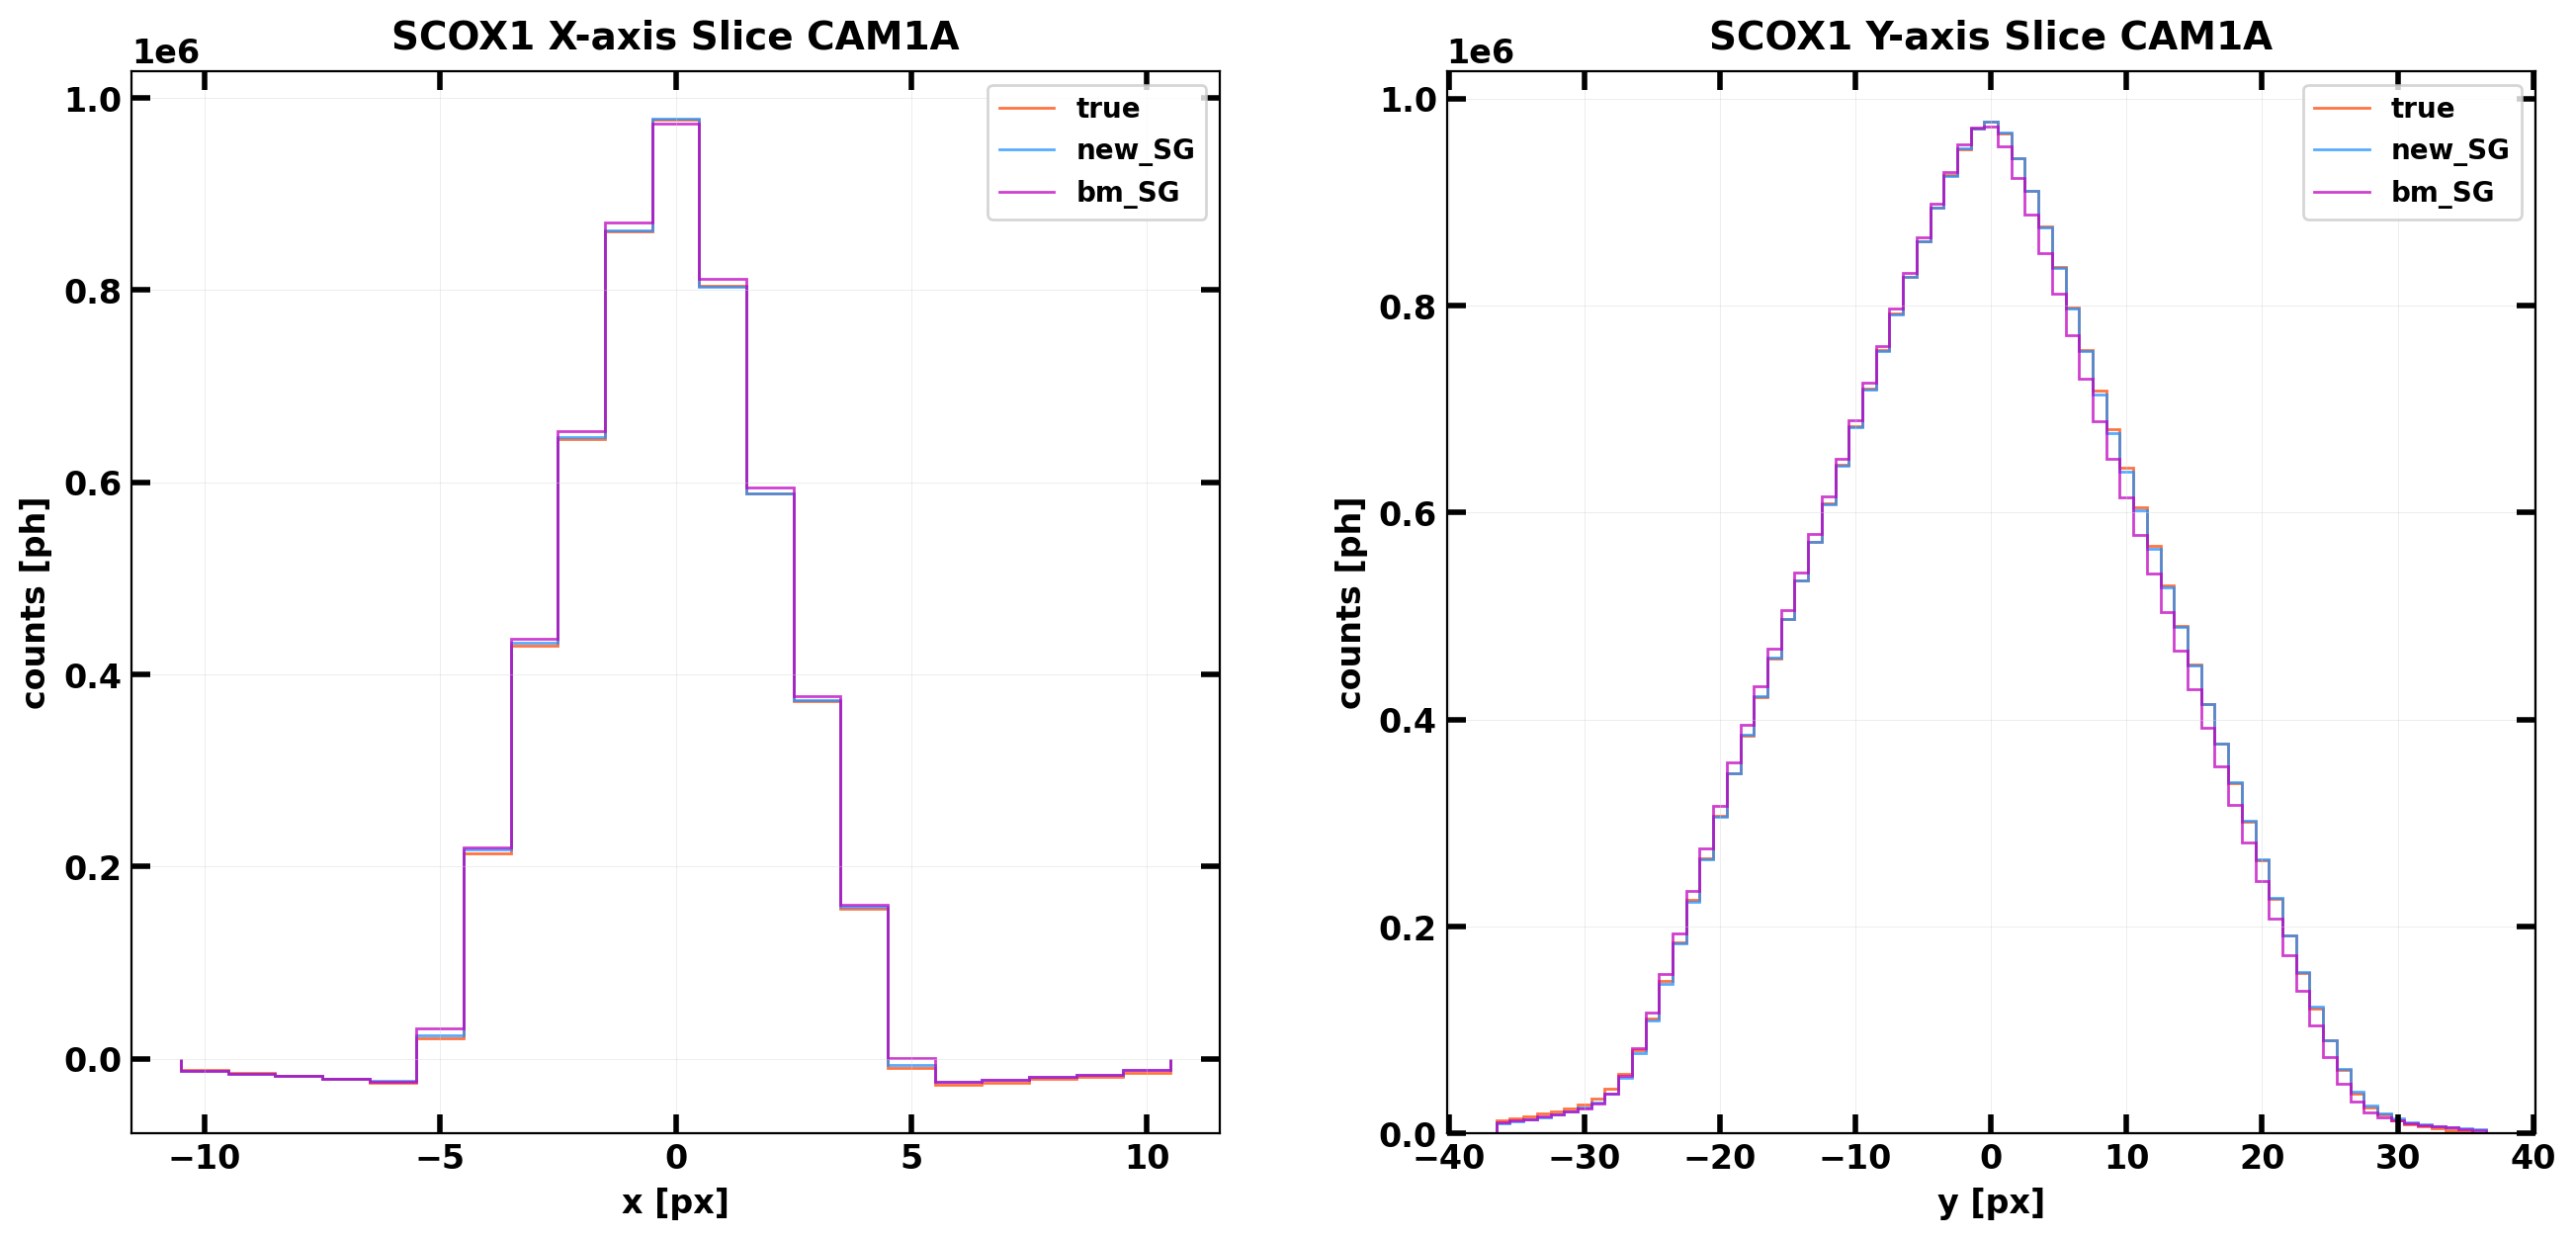

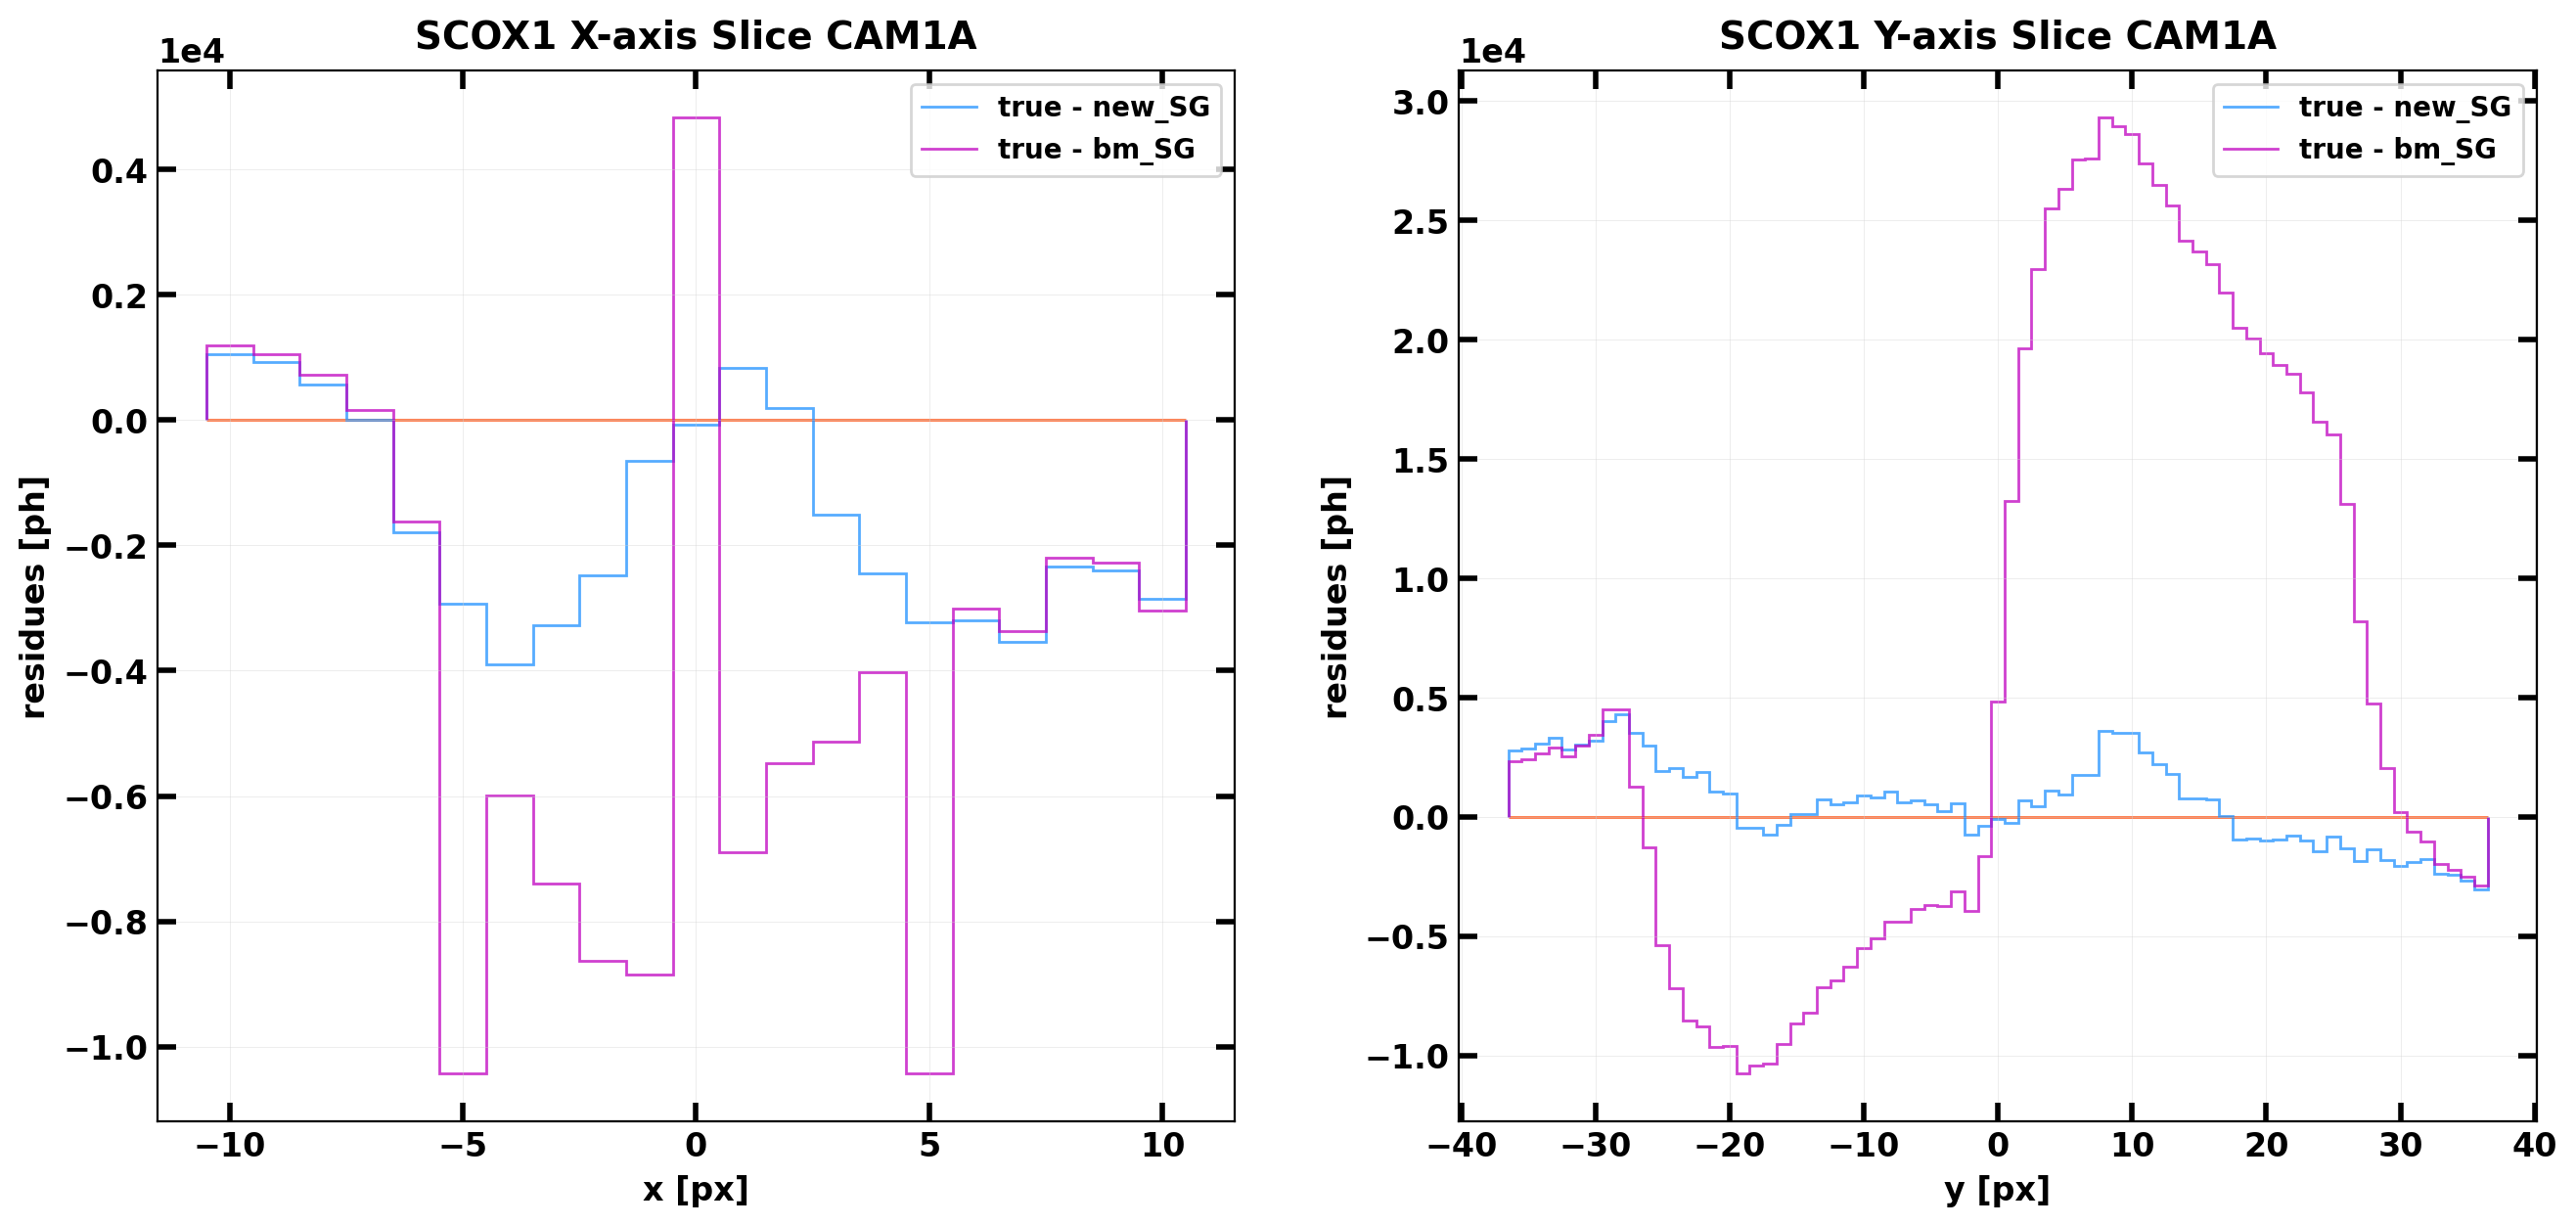

In [11]:
fluence = true_sky[i, j] + 8.25e4
alpha, beta = 0.0, 0.0

shiftx = shiftx + alpha * pxdim_x
shifty = shifty + beta * pxdim_y

source_fmodel = model_sky(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    fluence=fluence,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
source_bm_model = bm_sky(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    fluence=fluence,
    vignetting=VIGNETTING,
    psfy=PSFY,
)

res_sky_new = true_sky - source_fmodel
res_sky_bm = true_sky - source_bm_model

ds.slices_plot(
    sky=(true_sky, source_fmodel, source_bm_model),
    pos=(i, j),
    crp=crp,
    source=SOURCE_ID.upper(),
    labels=('true', 'new_SG', 'bm_SG'),
    cameraID=ID_CAMERA_A,
    save_to=(
        savefig_to(SAVE_TO, f'{SOURCE_ID}_skyslice_{DATASET}_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)
ds.slices_plot(
    sky=(np.zeros(wfm.shape_sky), res_sky_new, res_sky_bm),
    pos=(i, j),
    crp=crp,
    source=SOURCE_ID.upper(),
    ylabel='residues [ph]',
    labels=('', 'true - new_SG', 'true - bm_SG'),
    cameraID=ID_CAMERA_A,
    save_to=(
        savefig_to(SAVE_TO, f'{SOURCE_ID}_skyslice_res_{DATASET}_{ID_CAMERA_A.upper()}')
        if SAVE_THINGS else None
    ),
)

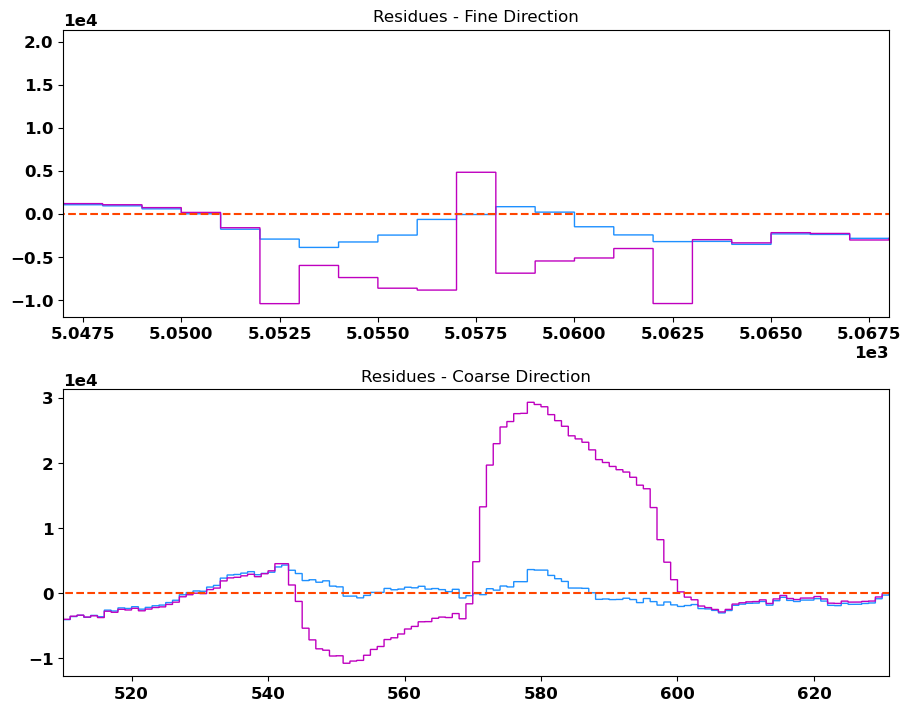

In [12]:
import matplotlib.pyplot as plt

xspan, yspan = 30, 5

fig, axs = plt.subplots(2, 1, constrained_layout=True, figsize=(9, 7))

axs[0].set_title('Residues - Fine Direction')
axs[0].plot(np.zeros_like(res_sky_new[i, :]), c='OrangeRed', linestyle='--')
axs[0].stairs(res_sky_new[i, :], edgecolor='DodgerBlue')
axs[0].stairs(res_sky_bm[i, :], edgecolor='m')
axs[0].set_xlim( (j - 2 * yspan , j + 2 * yspan + 1))

axs[1].set_title('Residues - Coarse Direction')
axs[1].plot(np.zeros_like(res_sky_new[:, j]), c='OrangeRed', linestyle='--')
axs[1].stairs(res_sky_new[:, j], edgecolor='DodgerBlue')
axs[1].stairs(res_sky_bm[:, j], edgecolor='m')
axs[1].set_xlim( (i - 2 * xspan , i + 2 * xspan + 1))

plt.show()

## **Residues Significance Distribution - BM vs New**

In [13]:
...

Ellipsis